# Import Libraries

In [554]:
# Import Basic Libraries
import os
import time
import itertools
from itertools import cycle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from pandas.plotting import scatter_matrix
import matplotlib.gridspec as gridspec

# Samplers
from imblearn.over_sampling import ADASYN 
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

# Scikit Packages
from sklearn import metrics
from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.model_selection import ShuffleSplit, RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.model_selection import validation_curve, learning_curve

from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import accuracy_score, classification_report, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import log_loss, confusion_matrix, roc_curve
from sklearn.metrics import plot_confusion_matrix, mean_squared_error

# Train Data
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import collections

%matplotlib inline

from scipy import stats
from scipy.stats import norm, skew
from scipy import interp

import warnings
warnings.filterwarnings("ignore")

<a id = "2"></a><br>
# Load Dataset

In [555]:
data = pd.read_csv('creditcard.csv')
pd.set_option("display.max.columns", None)
pd.set_option("display.precision", 3)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.62,0
1,0.0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.69,0
2,1.0,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.66,0
3,1.0,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.50,0
4,2.0,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.99,0


In [556]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881,10.072,-9.835,-2.067,-5.364,-2.607,-4.918,7.305,1.914,4.356,-1.593,2.712,-0.689,4.627,-0.924,1.108,1.992,0.511,-0.683,1.476,0.213,0.112,1.014,-0.509,1.437,0.250,0.944,0.824,0.77,0
284803,172787.0,-0.733,-0.055,2.035,-0.739,0.868,1.058,0.024,0.295,0.585,-0.976,-0.150,0.916,1.215,-0.675,1.165,-0.712,-0.026,-1.221,-1.546,0.060,0.214,0.924,0.012,-1.016,-0.607,-0.395,0.068,-0.054,24.79,0
284804,172788.0,1.920,-0.301,-3.250,-0.558,2.631,3.031,-0.297,0.708,0.432,-0.485,0.412,0.063,-0.184,-0.511,1.329,0.141,0.314,0.396,-0.577,0.001,0.232,0.578,-0.038,0.640,0.266,-0.087,0.004,-0.027,67.88,0
284805,172788.0,-0.240,0.530,0.703,0.690,-0.378,0.624,-0.686,0.679,0.392,-0.399,-1.934,-0.963,-1.042,0.450,1.963,-0.609,0.510,1.114,2.898,0.127,0.265,0.800,-0.163,0.123,-0.569,0.547,0.109,0.105,10.00,0
284806,172792.0,-0.533,-0.190,0.703,-0.506,-0.013,-0.650,1.577,-0.415,0.486,-0.915,-1.040,-0.032,-0.188,-0.084,0.041,-0.303,-0.660,0.167,-0.256,0.383,0.261,0.643,0.377,0.009,-0.474,-0.818,-0.002,0.014,217.00,0


Except for the **transaction** and **amount** we dont know what the other columns are (due to privacy reasons). The only thing we know, is that those columns that are unknown have been scaled already.   

<a id = "2"></a><br>
# Data Exploration

In [557]:
print('The dataset contains {0} rows and {1} columns.'.format(data.shape[0], data.shape[1]))

The dataset contains 284807 rows and 31 columns.


In [558]:
data.describe().round(4)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,1.021,0.999,0.995,0.959,0.915,0.876,0.849,0.838,0.814,0.771,0.735,0.726,0.625,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.407,-72.716,-48.326,-5.683,-113.743,-26.160,-43.557,-73.217,-13.434,-24.588,-4.798,-18.684,-5.792,-19.214,-4.499,-14.130,-25.163,-9.499,-7.213,-54.498,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,-0.762,-0.406,-0.648,-0.426,-0.583,-0.468,-0.484,-0.499,-0.456,-0.212,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.066,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,-0.033,0.140,-0.014,0.051,0.048,0.066,-0.066,-0.004,0.004,-0.062,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,0.740,0.618,0.662,0.493,0.649,0.523,0.400,0.501,0.459,0.133,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.590,20.007,15.595,23.745,12.019,7.848,7.127,10.527,8.878,17.315,9.254,5.041,5.592,39.421,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


### Summary Statistics
- **Mean**: Balance Point
- **Median**: Middle Value "when ordered"
- **Variance**: The average of the squared distance of the mean
- **Standard Deviation**: The square root of the variance
- **Skewness**: A measure that describes the contrast of one tail versus the other tail. For example, if there are more high values in your distribution than low values then your distribution is 'skewed' towards the high values.
- **Kurtosis**: A measure of how 'fat' the tails in the distribution are.

In [559]:
data.skew()

Time      -0.036
V1        -3.281
V2        -4.625
V3        -2.240
V4         0.676
V5        -2.426
V6         1.827
V7         2.554
V8        -8.522
V9         0.555
V10        1.187
V11        0.357
V12       -2.278
V13        0.065
V14       -1.995
V15       -0.308
V16       -1.101
V17       -3.845
V18       -0.260
V19        0.109
V20       -2.037
V21        3.593
V22       -0.213
V23       -5.875
V24       -0.552
V25       -0.416
V26        0.577
V27       -1.170
V28       11.192
Amount    16.978
Class     23.998
dtype: float64

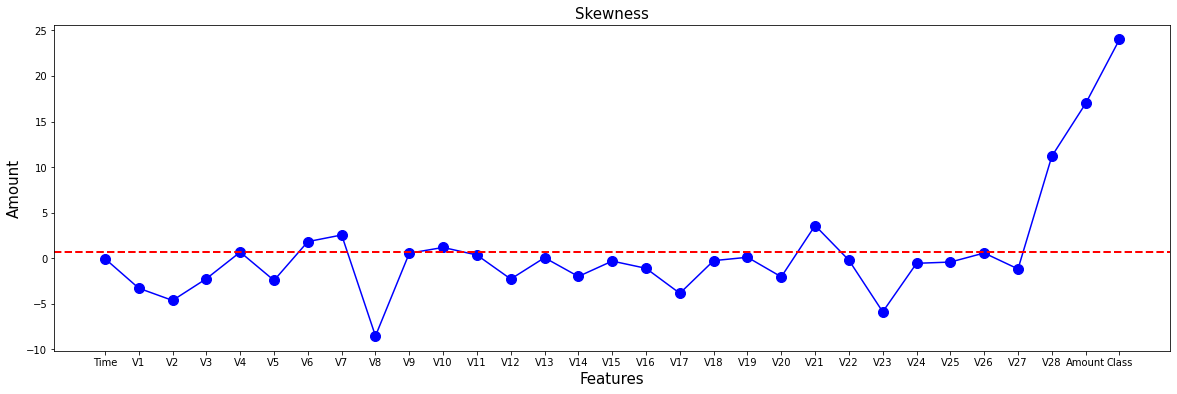

In [560]:
plt.figure(figsize = (20, 6))
plt.plot(data.skew(), marker = 'o', markersize = 10, color = 'b')
plt.axhline(data.skew().mean(), color = 'r', linestyle = 'dashed', linewidth = 2)
plt.title('Skewness', fontsize = 15)
plt.xlabel('Features', fontsize = 15)
plt.ylabel('Amount', fontsize = 15)
plt.show()

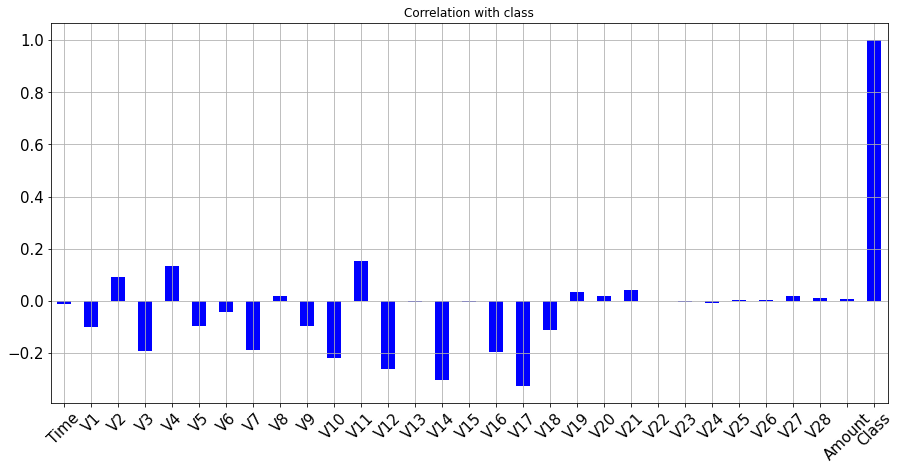

In [561]:
data.corrwith(data['Class']).plot.bar(
        figsize = (15, 7), title = "Correlation with class", fontsize = 15, color = 'b',
        rot = 45, grid = True)

* **All Features are widely skewed from -10 to 25**

In [562]:
# Null Value Check
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [563]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [564]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [565]:
# numerical summary -> only non-anonymized columns of interest
pd.set_option('precision', 3)
data.loc[:, ['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000,284807.000,284807.000
mean,94813.860,88.350,0.002
std,47488.146,250.120,0.042
min,0.000,0.000,0.000
25%,54201.500,5.600,0.000
50%,84692.000,22.000,0.000
75%,139320.500,77.165,0.000
max,172792.000,25691.160,1.000


* The transaction amount is relatively **small**. The mean of all the mounts made is approximately USD 88.

## Correlation 
* Correlation is a standardized version of covariance.
* Between -1 and 1
* Zero = Not correlated
* (+) : positive relation
* (-) : negtive relation

In [566]:
# Compute the correlation matrix
corr = data.corr()
corr.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000,1.174e-01,-1.059e-02,-4.196e-01,-1.053e-01,1.731e-01,-6.302e-02,8.471e-02,-3.695e-02,-8.660e-03,3.062e-02,-2.477e-01,1.243e-01,-6.590e-02,-9.876e-02,-1.835e-01,1.190e-02,-7.330e-02,9.044e-02,2.898e-02,-5.087e-02,4.474e-02,1.441e-01,5.114e-02,-1.618e-02,-2.331e-01,-4.141e-02,-5.135e-03,-9.413e-03,-0.011,-0.012
V1,0.117,1.000e+00,4.697e-17,-1.424e-15,1.755e-17,6.391e-17,2.398e-16,1.992e-15,-9.491e-17,2.170e-16,7.434e-17,2.439e-16,2.422e-16,-2.115e-16,9.353e-16,-3.252e-16,6.309e-16,-5.012e-16,2.870e-16,1.818e-16,1.037e-16,-1.755e-16,7.477e-17,9.809e-16,7.354e-17,-9.805e-16,-8.622e-17,3.208e-17,9.821e-16,-0.228,-0.101
V2,-0.011,4.697e-17,1.000e+00,2.512e-16,-1.126e-16,-2.040e-16,5.025e-16,3.966e-16,-4.414e-17,-5.729e-17,-4.782e-16,9.469e-16,-6.588e-16,3.855e-16,-2.541e-16,2.831e-16,4.934e-17,-9.883e-16,2.637e-16,9.528e-17,-9.310e-16,8.444e-17,2.501e-16,1.060e-16,-8.142e-18,-4.262e-17,2.602e-16,-4.478e-16,-3.676e-16,-0.531,0.091
V3,-0.420,-1.424e-15,2.512e-16,1.000e+00,-3.417e-16,-1.437e-15,1.432e-15,2.169e-15,3.433e-16,-4.234e-16,6.289e-16,-5.502e-17,2.207e-16,-6.883e-16,4.271e-16,1.123e-16,1.183e-15,4.577e-17,5.428e-16,2.577e-16,-9.429e-16,-2.972e-17,4.648e-16,2.115e-17,-9.352e-17,4.771e-16,6.522e-16,6.240e-16,7.727e-16,-0.211,-0.193
V4,-0.105,1.755e-17,-1.126e-16,-3.417e-16,1.000e+00,-1.941e-15,-2.713e-16,1.556e-16,5.196e-16,3.860e-16,6.055e-16,-2.084e-16,-5.658e-16,-1.506e-16,-8.522e-17,-1.508e-16,-6.939e-16,-4.398e-16,1.494e-16,-2.657e-16,-3.223e-16,-9.977e-17,2.100e-16,6.003e-17,2.230e-16,5.395e-16,-6.180e-16,-6.403e-17,-5.864e-17,0.099,0.133
V5,0.173,6.391e-17,-2.040e-16,-1.437e-15,-1.941e-15,1.000e+00,7.926e-16,-4.210e-16,7.589e-16,4.205e-16,-6.602e-16,7.343e-16,3.761e-16,-9.579e-16,-3.635e-16,-5.133e-16,-3.517e-16,1.426e-16,1.110e-15,-3.138e-16,2.076e-16,-1.369e-16,5.060e-16,1.638e-16,-9.286e-16,5.625e-16,9.145e-16,4.466e-16,-3.299e-16,-0.386,-0.095
V6,-0.063,2.398e-16,5.025e-16,1.432e-15,-2.713e-16,7.926e-16,1.000e+00,1.429e-16,-1.707e-16,1.114e-16,2.851e-16,4.866e-16,2.141e-16,-2.268e-16,3.453e-16,-6.368e-18,-2.478e-16,3.568e-16,2.811e-16,2.717e-16,1.899e-16,-1.576e-16,-3.363e-16,-7.232e-17,-1.262e-15,1.082e-15,-2.378e-16,-2.624e-16,4.813e-16,0.216,-0.044
V7,0.085,1.992e-15,3.966e-16,2.169e-15,1.556e-16,-4.210e-16,1.429e-16,1.000e+00,-8.692e-17,7.933e-16,3.043e-17,-1.084e-15,1.510e-15,-9.892e-17,-1.729e-16,1.937e-17,2.894e-16,1.150e-15,-1.117e-16,-2.874e-16,1.744e-16,1.939e-16,-1.058e-15,2.328e-16,-2.590e-17,1.174e-15,-7.335e-16,-5.887e-16,-6.837e-17,0.397,-0.187
V8,-0.037,-9.491e-17,-4.414e-17,3.433e-16,5.196e-16,7.589e-16,-1.707e-16,-8.692e-17,1.000e+00,2.901e-16,9.052e-17,1.955e-16,-6.266e-17,-2.383e-16,-1.131e-16,2.021e-16,5.027e-16,-3.509e-16,-4.094e-16,-5.340e-16,-1.096e-16,-2.412e-16,5.476e-16,3.897e-16,-1.803e-16,-1.391e-16,-1.210e-16,1.734e-16,-4.484e-16,-0.103,0.020
V9,-0.009,2.170e-16,-5.729e-17,-4.234e-16,3.860e-16,4.205e-16,1.114e-16,7.933e-16,2.901e-16,1.000e+00,-2.772e-16,4.682e-16,-2.445e-15,-2.650e-16,2.343e-16,-1.588e-15,-3.252e-16,6.536e-16,1.204e-16,1.121e-16,-4.341e-16,4.578e-17,2.872e-17,5.929e-16,-2.346e-16,1.100e-15,-1.389e-15,-2.287e-16,9.147e-16,-0.044,-0.098


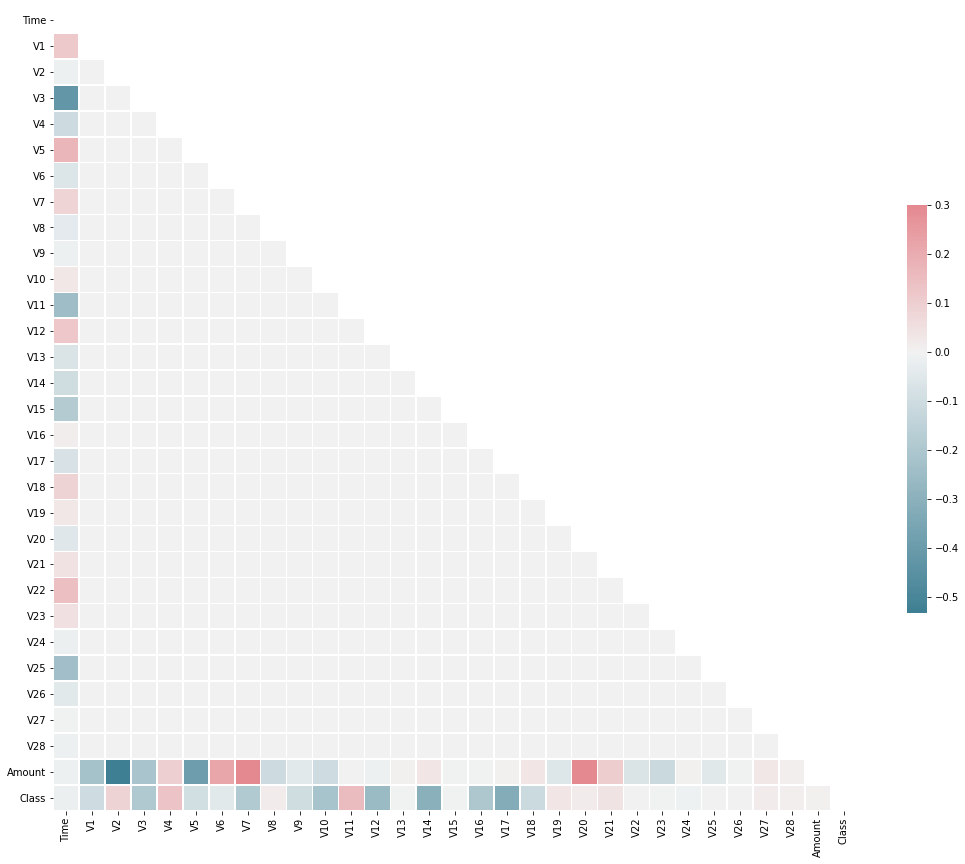

In [567]:
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype = np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize = (18, 15))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap = True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask = mask, cmap = cmap, vmax = .3, center = 0,
            square = True, linewidths = .5, cbar_kws = {"shrink": .5})

Text(0.5, 1.0, "Imbalanced Correlation Matrix \n (don't use for reference)")

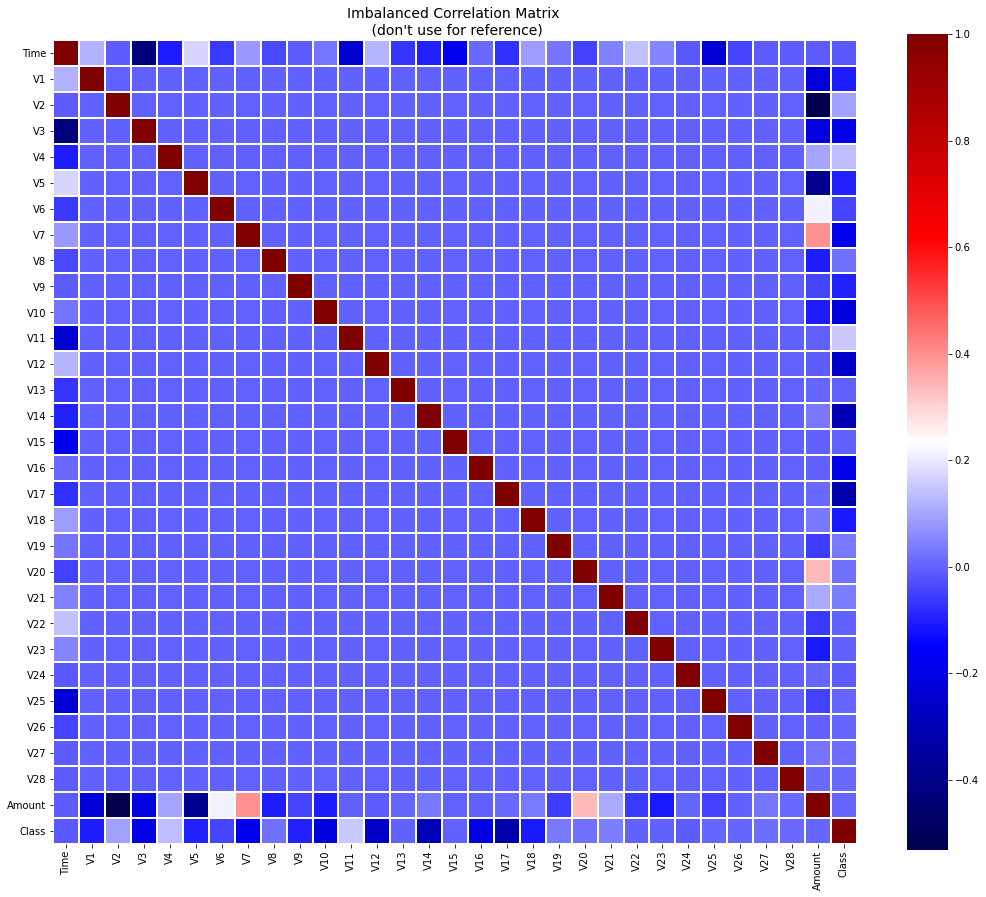

In [568]:
plt.figure(figsize = (18, 15))
sns.heatmap(corr, cmap = 'seismic', square = True, linewidths = 1);
plt.title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize = 14)

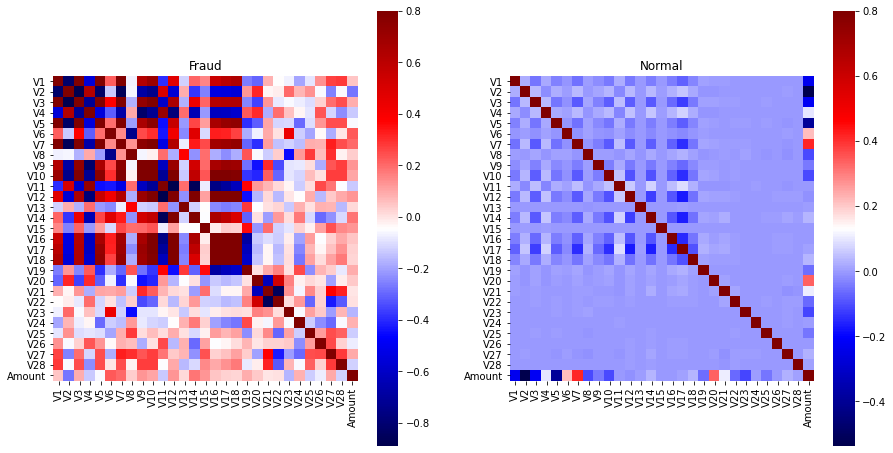

In [569]:
#correlation matrix 
f, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 8))

sns.heatmap(data.query('Class == 1').drop(['Class', 'Time'], 1).corr(), vmax = .8, square = True, ax = ax1, cmap = 'seismic')
ax1.set_title('Fraud')

sns.heatmap(data.query('Class == 0').drop(['Class', 'Time'], 1).corr(), vmax = .8, square = True, ax = ax2, cmap = 'seismic');
ax2.set_title('Normal')

plt.show()

In [570]:
# The classes are heavily skewed we need to solve this issue later.

print('Normal transactions count:', data['Class'].value_counts().values[0])
print('No Frauds:', round(data['Class'].value_counts()[0]/len(data) * 100, 3), '% of the dataset\n')

print('Fraudulent transactions count:', data['Class'].value_counts().values[1])
print('Frauds:', round(data['Class'].value_counts()[1]/len(data) * 100, 3), '% of the dataset')

Normal transactions count: 284315
No Frauds: 99.827 % of the dataset

Fraudulent transactions count: 492
Frauds: 0.173 % of the dataset


In [571]:
vc = data['Class'].value_counts().to_frame().reset_index()
vc['percent'] = vc["Class"].apply(lambda x : round(100*float(x) / len(data), 2))
vc = vc.rename(columns = {"index" : "Target", "Class" : "Count"})
vc

,Target,Count,percent
0,0,284315,99.83
1,1,492,0.17


Our dataset looks really imbalanced. Most of the transactions are non-fraud. If we use this dataframe as the base for our predictive models and analysis we might get a lot of errors and our algorithms will probably overfit since it will "assume" that most transactions are not fraud. But we don't want our model to assume, we want our model to detect patterns that give signs of fraud!

In [572]:
data['Class'].unique()

array([0, 1])

In [573]:
frauds = data[data['Class'] == 1]
normal = data[data['Class'] == 0]

print("Frauds:", frauds.shape)
print("Normal:", normal.shape)

Frauds: (492, 31)
Normal: (284315, 31)


In [574]:
data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [575]:
nf_desc = normal['Amount'].describe()
nf_desc.name = 'Not Fraud'

fr_desc = frauds['Amount'].describe()
fr_desc.name = 'Fraud'

pd.concat([nf_desc, fr_desc], axis = 1)

,Not Fraud,Fraud
count,284315.000,492.000
mean,88.291,122.211
std,250.105,256.683
min,0.000,0.000
25%,5.650,1.000
50%,22.000,9.250
75%,77.050,105.890
max,25691.160,2125.870


<a id = "2"></a><br>
# Plot Data


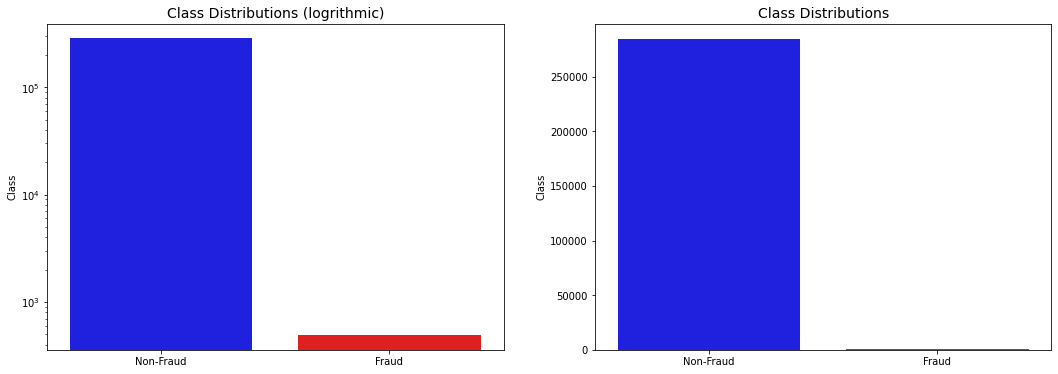

In [576]:
# scale the graph logarithmically to be able to see Fraud
fig, ax = plt.subplots(1, 2, figsize = (18, 6))
count = data["Class"].value_counts()
labels = ['Non-Fraud', 'Fraud']

sns.barplot(x = labels, y = count, log = True, palette = ['blue', 'red'], ax = ax[0])
ax[0].set_title('Class Distributions (logrithmic)', fontsize = 14)

sns.barplot(x = labels, y = count, palette = ['blue', 'red'], ax = ax[1])
ax[1].set_title('Class Distributions', fontsize = 14)

plt.show()

**Distributions:** By seeing the distributions we can have an idea how skewed are these features, we can also see further distributions of the other features.

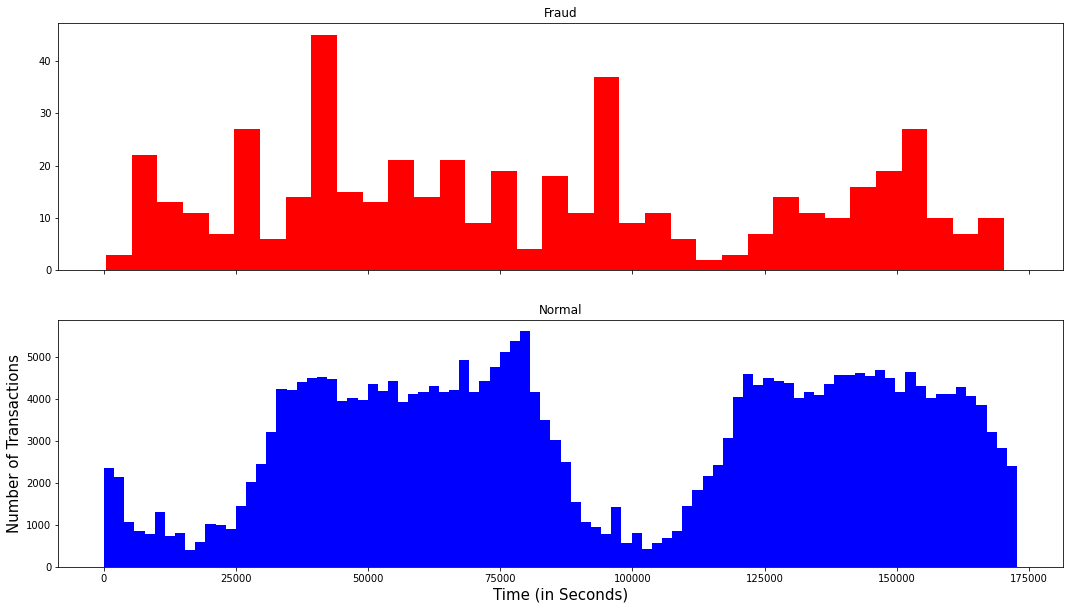

In [577]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (18, 10))

normal_time = normal['Time'].values
fraud_time = frauds['Time'].values

ax1.hist(fraud_time, bins = 35, color = 'r')

ax1.set_title('Fraud')

ax2.hist(normal_time, bins = 90, color = 'b')
ax2.set_title('Normal')

plt.xlabel('Time (in Seconds)', fontsize = 15)
plt.ylabel('Number of Transactions', fontsize = 15)
plt.show()

* **There are two days worth of data**


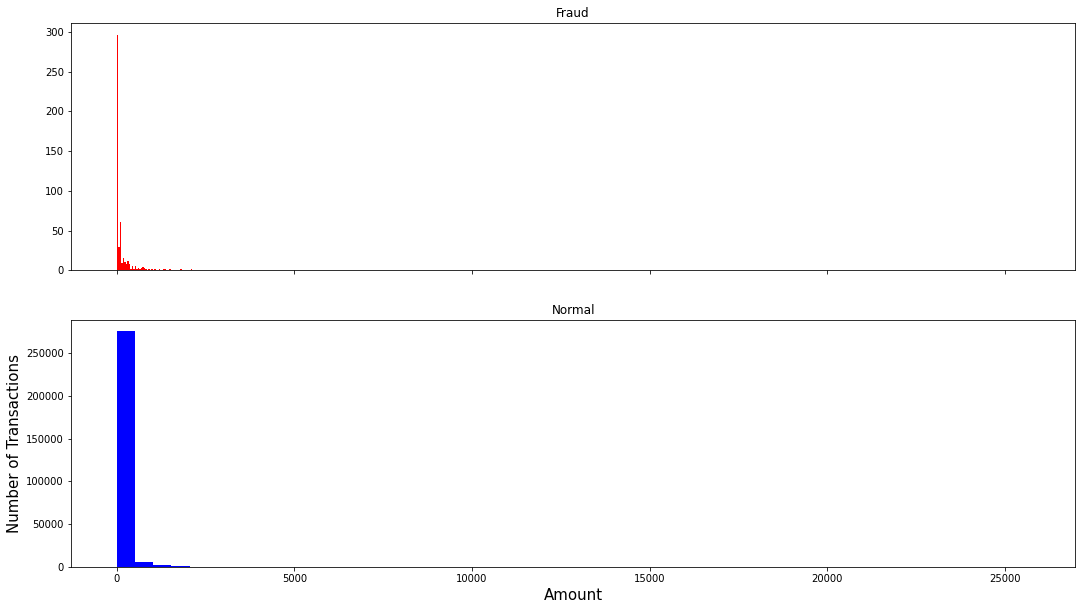

In [578]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (18, 10))

normal_amount = normal['Amount'].values
fraud_amount = frauds['Amount'].values

ax1.hist(fraud_amount, bins = 50, color = 'r')
ax1.set_title('Fraud')

ax2.hist(normal_amount, bins = 50, color = 'b')
ax2.set_title('Normal')

plt.xlabel('Amount', fontsize = 15)
plt.ylabel('Number of Transactions', fontsize = 15)
plt.show()

In [579]:
print('Max Normal Transactons:', normal['Amount'].max())
print('Max Fraud Transations:', frauds['Amount'].max())

Max Normal Transactons: 25691.16
Max Fraud Transations: 2125.87


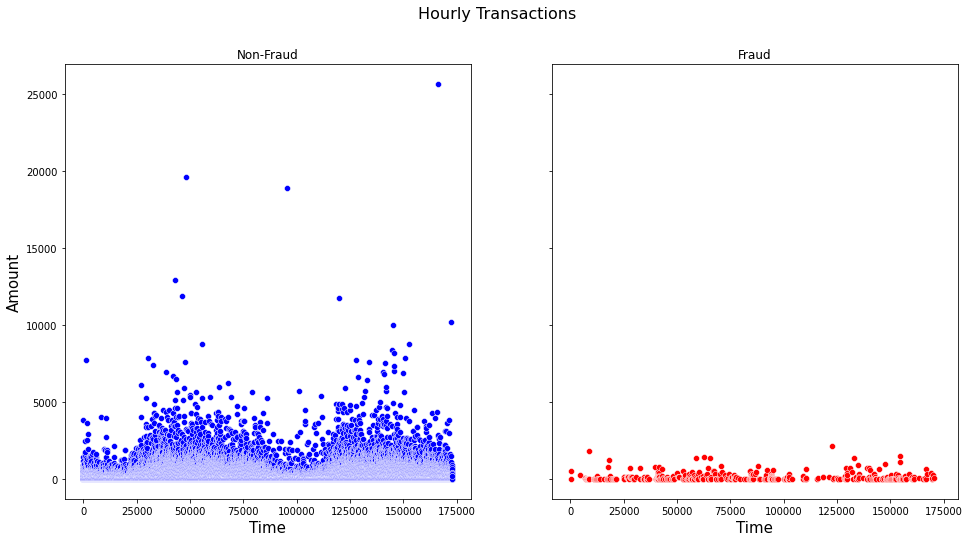

In [580]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (16, 8), sharey = True, sharex = True)

fig.suptitle('Hourly Transactions', fontsize = 16)

sns.scatterplot(normal['Time'], normal['Amount'], color = 'blue', ax = ax0)
sns.scatterplot(frauds['Time'], frauds['Amount'], color = 'red', ax = ax1)

ax0.set_title('Non-Fraud')
ax1.set_title('Fraud')
ax0.set_xlabel('Time', fontsize = 15);
ax1.set_xlabel('Time', fontsize = 15);
ax0.set_ylabel('Amount', fontsize = 15);
plt.show()

In [581]:
data['hour'] = data['Time'].apply(lambda x: np.ceil(float(x)/3600) % 24)

In [582]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
0,0.0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.62,0,0.0
1,0.0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.69,0,0.0
2,1.0,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.66,0,1.0
3,1.0,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.50,0,1.0
4,2.0,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.99,0,1.0


In [583]:
data.pivot_table(values = 'Amount', index = 'hour', columns = 'Class', aggfunc = 'count')

Class,0,1
hour,,
0.0,10919,21
1.0,7687,6
2.0,4212,10
3.0,3269,57
4.0,3476,17
5.0,2185,23
6.0,2979,11
7.0,4093,9
8.0,7219,23


In [584]:
def PlotHistogram(df, norm):
    bins = np.arange(data['hour'].min(), data['hour'].max()+2)
    plt.figure(figsize = (15, 4))
    sns.distplot(data[data['Class'] == 0.0]['hour'],
                 norm_hist = norm,
                 bins = bins,
                 kde = False,
                 color = 'b',
                 hist_kws = {'alpha':.5},
                 label = 'Legit')
    sns.distplot(data[data['Class'] == 1.0]['hour'],
                 norm_hist = norm,
                 bins = bins,
                 kde = False,
                 color = 'r',
                 label = 'Fraud',
                 hist_kws = {'alpha':.5})
    plt.xticks(range(0, 26))
    plt.legend()
    plt.show()

In [585]:
print('Normalized histogram of Legit/Fraud over every hour of the day')

Normalized histogram of Legit/Fraud over every hour of the day


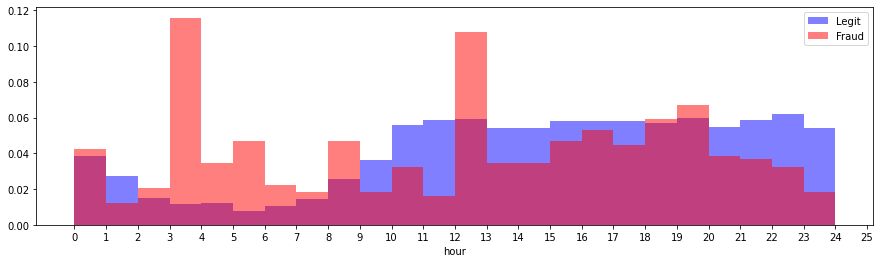

In [586]:
PlotHistogram(data, True)

Counts histogram of Legit/Fraud over every hour of the day
*you can barely see the Fraud cases since there are so little of them.


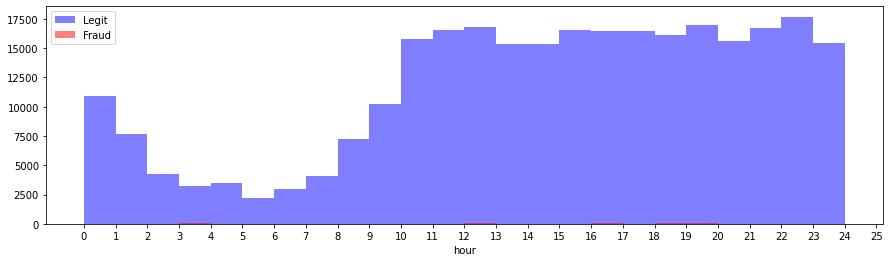

In [587]:
print('Counts histogram of Legit/Fraud over every hour of the day')
print('*you can barely see the Fraud cases since there are so little of them.')
PlotHistogram(data, False)

<a id = "2"></a><br>
# Data Preprocessing


<a id = "2"></a><br>
# Train Test Split & Standardization

In [588]:
# Since most of our data has already been scaled, we should scale the columns that are left to scale (Amount and Time)
# RobustScaler is less prone to outliers.

scaler = RobustScaler()
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['Time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))
data.drop(['hour'], axis = 1, inplace = True)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.995,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,1.783,0
1,-0.995,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,-0.270,0
2,-0.995,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,4.984,0
3,-0.995,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,1.418,0
4,-0.995,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,0.671,0


In [589]:
X = data.drop('Class', axis = 1)
y = data['Class']

print("Shape of X :", X.shape)
print('Shape of y :', y.shape)

Shape of X : (284807, 30)
Shape of y : (284807,)


In [590]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 0)

print("Shape of x_train : ", X_train.shape)
print("Shape of y_train : ", y_train.shape)

print("\nShape of x_test : ", X_test.shape)
print("Shape of y_test : ", y_test.shape)

Shape of x_train :  (227845, 30)
Shape of y_train :  (227845,)

Shape of x_test :  (56962, 30)
Shape of y_test :  (56962,)


In [591]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

<a id = "2"></a><br>
# Logistic Classifier without SMOTE

In [592]:
LR = LogisticRegression()

In [594]:
LR.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [595]:
y_pred = LR.predict(X_test)

In [596]:
cn = confusion_matrix(y_test, y_pred)

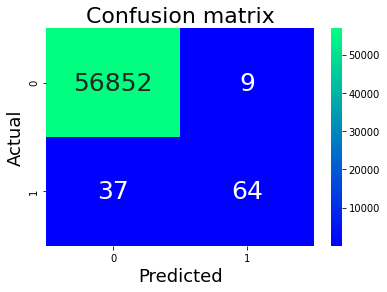

In [597]:
sns.heatmap(pd.DataFrame(cn), annot = True, annot_kws={"size": 25}, cmap = "winter", fmt = 'g')
plt.title('Confusion matrix', y = 1.1, fontsize = 22)
plt.xlabel('Predicted', fontsize = 18)
plt.ylabel('Actual', fontsize = 18)
plt.show()

In [598]:
labels = ['Non-fraud', 'Fraud']
print(classification_report(y_test, y_pred, target_names = labels))

              precision    recall  f1-score   support

   Non-fraud       1.00      1.00      1.00     56861
       Fraud       0.88      0.63      0.74       101

    accuracy                           1.00     56962
   macro avg       0.94      0.82      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Text(0.5, 1.0, 'Precision Recall Curve')

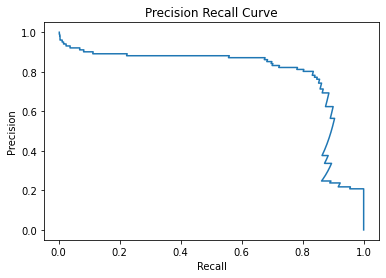

In [599]:
y_pred_prob = LR.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.plot(precision, recall)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')

In [600]:
print('Accuracy :{0:0.5f}'.format(metrics.accuracy_score(y_pred, y_test))) 
print('AUC : {0:0.5f}'.format(metrics.roc_auc_score(y_test, y_pred)))
print('Precision : {0:0.5f}'.format(metrics.precision_score(y_test, y_pred)))
print('Recall : {0:0.5f}'.format(metrics.recall_score(y_test, y_pred)))
print('F1 : {0:0.5f}'.format(metrics.f1_score(y_test, y_pred)))
print("\n")

Accuracy :0.99919
AUC : 0.81675
Precision : 0.87671
Recall : 0.63366
F1 : 0.73563




AUC -  0.8167525428084921 



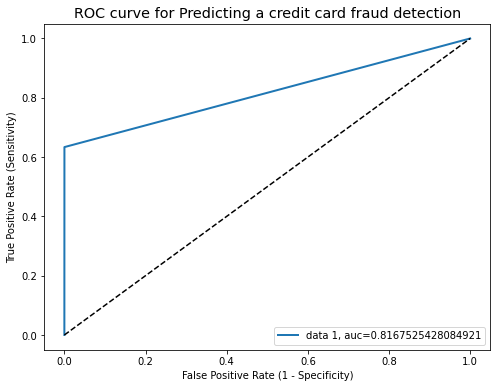

In [601]:
plt.figure(figsize = (8, 6))

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)

auc = metrics.roc_auc_score(y_test, y_pred)
print("AUC - ",auc,"\n")

plt.plot(fpr,tpr,linewidth=2, label="data 1, auc="+str(auc))
plt.legend(loc = 4)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12
plt.title('ROC curve for Predicting a credit card fraud detection')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

In [602]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

Before OverSampling, counts of label '1': 391
Before OverSampling, counts of label '0': 227454 



<a id = "2"></a><br>
# Logistic Classifier with SMOTE

In [603]:
sm = SMOTE(ratio = 'auto', kind = 'regular')

In [604]:
X_sampled, y_sampled = sm.fit_sample(X,y.values.ravel())

In [605]:
print('After OverSampling, the shape of train_x: {}'.format(X_sampled.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_sampled.shape))

After OverSampling, the shape of train_x: (568630, 30)
After OverSampling, the shape of train_y: (568630,) 



In [606]:
print("After OverSampling, counts of label '1', %: {}".format(sum(y_sampled == 1)/len(y_sampled)*100.0,2))
print("After OverSampling, counts of label '0', %: {}".format(sum(y_sampled == 0)/len(y_sampled)*100.0,2))

After OverSampling, counts of label '1', %: 50.0
After OverSampling, counts of label '0', %: 50.0


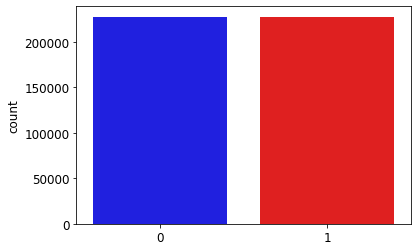

In [607]:
sns.countplot(x = y_train_s, data = data, palette = ['blue', 'red'])

In [608]:
X_train_sampled, X_test_sampled, y_train_sampled, y_test_sampled = train_test_split(X_sampled, y_sampled, test_size = 0.3, random_state = 0)

In [609]:
print("Number transactions train dataset: ", len(X_train))
print("Number transactions test dataset: ", len(X_test))
print("Total number of transactions: ", len(X_train)+len(X_test))

Number transactions train dataset:  227845
Number transactions test dataset:  56962
Total number of transactions:  284807


In [610]:
print("")
print("Number transactions train dataset: ", len(X_train_sampled))
print("Number transactions test dataset: ", len(X_test_sampled))
print("Total number of transactions: ", len(X_train_sampled)+len(X_test_sampled))


Number transactions train dataset:  398041
Number transactions test dataset:  170589
Total number of transactions:  568630


In [611]:
X_train_sampled_df = pd.DataFrame(X_train_sampled)
y_train_sampled_df = pd.DataFrame(y_train_sampled)
X_test_sampled_df = pd.DataFrame(X_test_sampled)
y_test_sampled_df = pd.DataFrame(y_test_sampled)

* Now the dataset is balanced, so we can build a Logistic Regression model with SMOTE. One important thing to point out here is that we used SMOTE after cross validation in order to avoid data leakage problem and hence overfitting


In [612]:
LR = LogisticRegression()

In [613]:
LR.fit(X_train_sampled_df, y_train_sampled_df.values.ravel())

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [614]:
y_pred_sample = LR.predict(X_test_sampled_df.values)

In [615]:
cn = confusion_matrix(y_test_sampled_df, y_pred_sample)

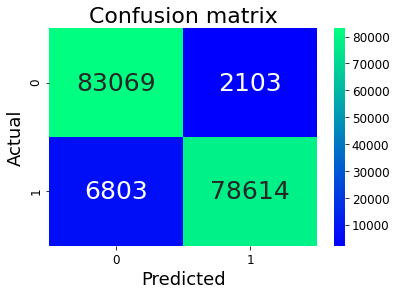

In [543]:
sns.heatmap(pd.DataFrame(cn), annot = True, annot_kws = {"size": 25}, cmap = "winter", fmt = 'g')
plt.title('Confusion matrix', y = 1.1, fontsize = 22)
plt.xlabel('Predicted', fontsize = 18)
plt.ylabel('Actual', fontsize = 18)
plt.show()

In [616]:
labels = ['Non-fraud', 'Fraud']
print(classification_report(y_test_sampled_df, y_pred_sample, target_names = labels))

              precision    recall  f1-score   support

   Non-fraud       0.93      0.98      0.95     85172
       Fraud       0.97      0.92      0.95     85417

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589



Text(0.5, 1.0, 'Precision Recall Curve')

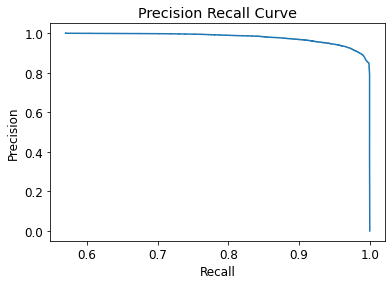

In [617]:
y_pred_prob = LR.predict_proba(X_test_sampled_df)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_sampled_df, y_pred_prob)
plt.plot(precision, recall)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')

In [619]:
print('Accuracy :{0:0.5f}'.format(metrics.accuracy_score(y_test_sampled_df, y_pred_sample))) 
print('AUC : {0:0.5f}'.format(metrics.roc_auc_score(y_test_sampled_df, y_pred_sample)))
print('Precision : {0:0.5f}'.format(metrics.precision_score(y_test_sampled_df, y_pred_sample)))
print('Recall : {0:0.5f}'.format(metrics.recall_score(y_test_sampled_df, y_pred_sample)))
print('F1 : {0:0.5f}'.format(metrics.f1_score(y_test_sampled_df, y_pred_sample)))
print("\n")

Accuracy :0.94848
AUC : 0.94852
Precision : 0.97393
Recall : 0.92180
F1 : 0.94714




AUC -  0.9485227546632153 



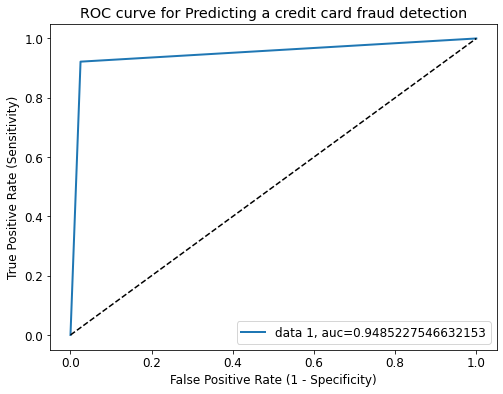

In [620]:
plt.figure(figsize=(8,6))

fpr, tpr, thresholds = metrics.roc_curve(y_test_sampled_df, y_pred_sample)

auc = metrics.roc_auc_score(y_test_sampled_df, y_pred_sample)
print("AUC - ",auc,"\n")

plt.plot(fpr,tpr,linewidth = 2, label = "data 1, auc="+str(auc))
plt.legend(loc = 4)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12
plt.title('ROC curve for Predicting a credit card fraud detection')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

<a id = "2"></a><br>
# Decision Tree Classifier without SMOTE

In [621]:
DTC = DecisionTreeClassifier(random_state = 0, criterion = 'gini', splitter = 'best', 
                                    min_samples_leaf = 1, min_samples_split = 2)

In [622]:
DTC.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=0, splitter='best')

In [623]:
y_pred = DTC.predict(X_test)

In [627]:
cn = confusion_matrix(y_test, y_pred)

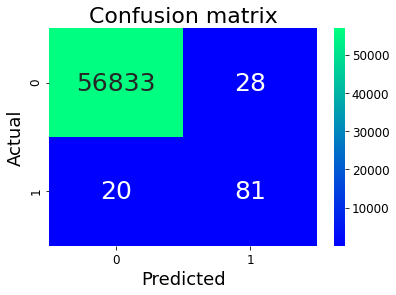

In [628]:
sns.heatmap(pd.DataFrame(cn), annot = True, annot_kws={"size": 25}, cmap = "winter", fmt = 'g')
plt.title('Confusion matrix', y = 1.1, fontsize = 22)
plt.xlabel('Predicted', fontsize = 18)
plt.ylabel('Actual', fontsize = 18)
plt.show()

In [629]:
labels = ['Non-fraud', 'Fraud']
print(classification_report(y_test, y_pred, target_names = labels))

              precision    recall  f1-score   support

   Non-fraud       1.00      1.00      1.00     56861
       Fraud       0.74      0.80      0.77       101

    accuracy                           1.00     56962
   macro avg       0.87      0.90      0.89     56962
weighted avg       1.00      1.00      1.00     56962



Text(0.5, 1.0, 'Precision Recall Curve')

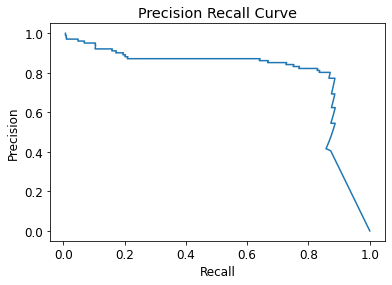

In [630]:
y_pred_prob = LR.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.plot(precision, recall)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')

In [631]:
print('Accuracy :{0:0.5f}'.format(metrics.accuracy_score(y_pred, y_test))) 
print('AUC : {0:0.5f}'.format(metrics.roc_auc_score(y_test, y_pred)))
print('Precision : {0:0.5f}'.format(metrics.precision_score(y_test, y_pred)))
print('Recall : {0:0.5f}'.format(metrics.recall_score(y_test, y_pred)))
print('F1 : {0:0.5f}'.format(metrics.f1_score(y_test, y_pred)))
print("\n")

Accuracy :0.99916
AUC : 0.90074
Precision : 0.74312
Recall : 0.80198
F1 : 0.77143




AUC -  0.9007438845571126 



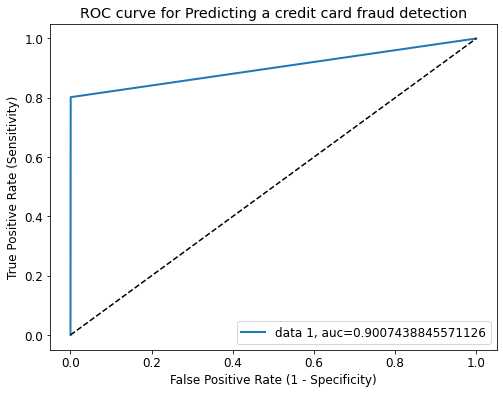

In [632]:
plt.figure(figsize = (8, 6))

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)

auc = metrics.roc_auc_score(y_test, y_pred)
print("AUC - ",auc,"\n")

plt.plot(fpr,tpr,linewidth=2, label="data 1, auc="+str(auc))
plt.legend(loc = 4)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12
plt.title('ROC curve for Predicting a credit card fraud detection')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

<a id = "2"></a><br>
# Decision Tree Classifier with SMOTE

In [633]:
sm = SMOTE(ratio = 'auto', kind = 'regular')

In [634]:
X_sampled, y_sampled = sm.fit_sample(X, y.values.ravel())

In [635]:
X_train_sampled, X_test_sampled, y_train_sampled, y_test_sampled = train_test_split(X_sampled, y_sampled, test_size = 0.3, random_state = 0)

In [636]:
X_train_sampled_df = pd.DataFrame(X_train_sampled)
y_train_sampled_df = pd.DataFrame(y_train_sampled)
X_test_sampled_df = pd.DataFrame(X_test_sampled)
y_test_sampled_df = pd.DataFrame(y_test_sampled)

In [637]:
DTR = DecisionTreeClassifier()

In [638]:
DTR.fit(X_train_sampled_df, y_train_sampled_df.values.ravel())

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [639]:
y_pred_sample = DTR.predict(X_test_sampled_df.values)

In [640]:
cn = confusion_matrix(y_test_sampled_df, y_pred_sample)

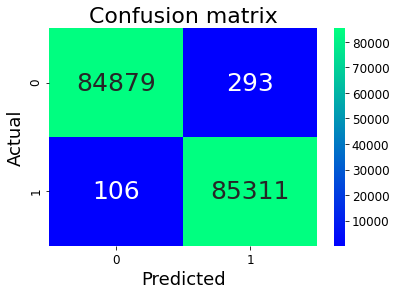

In [641]:
sns.heatmap(pd.DataFrame(cn), annot = True, annot_kws = {"size": 25}, cmap = "winter", fmt = 'g')
plt.title('Confusion matrix', y = 1.1, fontsize = 22)
plt.xlabel('Predicted', fontsize = 18)
plt.ylabel('Actual', fontsize = 18)
plt.show()

In [642]:
labels = ['Non-fraud', 'Fraud']
print(classification_report(y_test_sampled_df, y_pred_sample, target_names = labels))

              precision    recall  f1-score   support

   Non-fraud       1.00      1.00      1.00     85172
       Fraud       1.00      1.00      1.00     85417

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589



Text(0.5, 1.0, 'Precision Recall Curve')

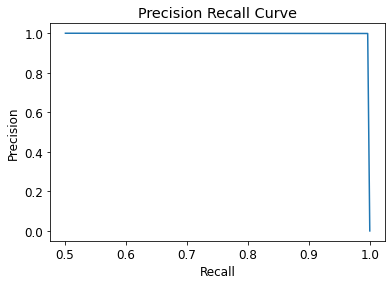

In [643]:
y_pred_prob = DTR.predict_proba(X_test_sampled_df)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_sampled_df, y_pred_prob)
plt.plot(precision, recall)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')

In [644]:
print('Accuracy :{0:0.5f}'.format(metrics.accuracy_score(y_test_sampled_df, y_pred_sample))) 
print('AUC : {0:0.5f}'.format(metrics.roc_auc_score(y_test_sampled_df, y_pred_sample)))
print('Precision : {0:0.5f}'.format(metrics.precision_score(y_test_sampled_df, y_pred_sample)))
print('Recall : {0:0.5f}'.format(metrics.recall_score(y_test_sampled_df, y_pred_sample)))
print('F1 : {0:0.5f}'.format(metrics.f1_score(y_test_sampled_df, y_pred_sample)))
print("\n")

Accuracy :0.99766
AUC : 0.99766
Precision : 0.99658
Recall : 0.99876
F1 : 0.99767




AUC -  0.9976594657741857 



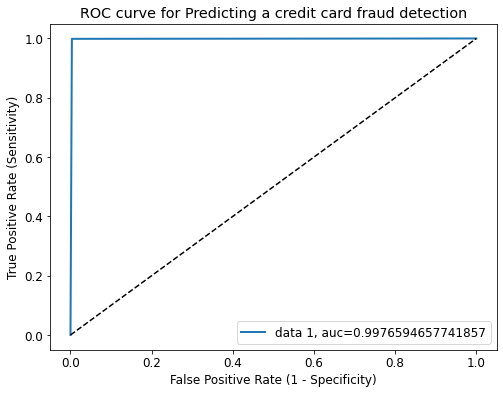

In [645]:
plt.figure(figsize=(8,6))

fpr, tpr, thresholds = metrics.roc_curve(y_test_sampled_df, y_pred_sample)

auc = metrics.roc_auc_score(y_test_sampled_df, y_pred_sample)
print("AUC - ",auc,"\n")

plt.plot(fpr,tpr,linewidth = 2, label = "data 1, auc="+str(auc))
plt.legend(loc = 4)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12
plt.title('ROC curve for Predicting a credit card fraud detection')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

<a id = "2"></a><br>
# Artificial Neural Network

In [665]:
# ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [666]:
def build_model():
    model = keras.models.Sequential([
        layers.Dense(units = 16, activation = 'relu', input_dim = 30),
        layers.Dense(units = 24, kernel_initializer = 'uniform', activation = 'relu'),
        layers.Dense(units = 20, kernel_initializer = 'uniform', activation = 'relu'),
        layers.Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid')])
    model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy', 'mean_absolute_error', 'mean_squared_error'])
    return model

In [667]:
model = build_model()

In [668]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_15 (Dense)             (None, 16)                496       
_________________________________________________________________
dense_16 (Dense)             (None, 24)                408       
_________________________________________________________________
dense_17 (Dense)             (None, 20)                500       
_________________________________________________________________
dense_18 (Dense)             (None, 1)                 21        
Total params: 1,425
Trainable params: 1,425
Non-trainable params: 0
_________________________________________________________________


In [686]:
# Display the training progress by printing a single dot for each complted epoch
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch%1 == 0:print('.', end = '')
EPOCHS = 100
history = model.fit(X_train_s, y_train_s, epochs = EPOCHS,
                    validation_split = 0.2, verbose = 0, callbacks = [PrintDot()]) #calculate print dot

....................................................................................................

In [687]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,accuracy,mean_absolute_error,mean_squared_error,val_loss,val_accuracy,val_mean_absolute_error,val_mean_squared_error,epoch
95,9.818e-04,1.0,2.427e-04,1.487e-04,1.075e-04,1.0,1.056e-04,3.549e-06,95
96,8.052e-04,1.0,2.386e-04,1.409e-04,1.679e-05,1.0,1.676e-05,6.170e-08,96
97,8.551e-04,1.0,2.182e-04,1.203e-04,3.075e-04,1.0,3.011e-04,1.158e-05,97
98,7.384e-04,1.0,2.149e-04,1.295e-04,2.269e-04,1.0,2.251e-04,3.506e-06,98
99,7.272e-04,1.0,2.114e-04,1.135e-04,1.620e-04,1.0,1.606e-04,2.679e-06,99


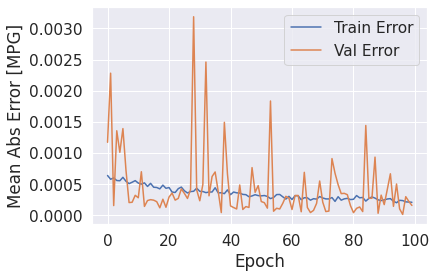

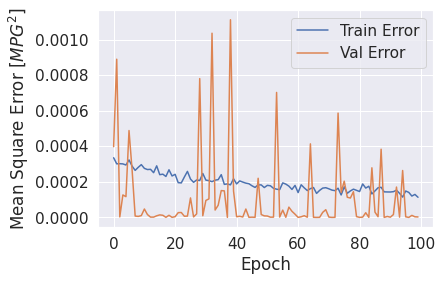

In [689]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [MPG]')
  plt.plot(hist['epoch'], hist['mean_absolute_error'], label = 'Train Error')
  plt.plot(hist['epoch'], hist['val_mean_absolute_error'], label = 'Val Error')
  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [$MPG^2$]')
  plt.plot(hist['epoch'], hist['mean_squared_error'], label = 'Train Error')
  plt.plot(hist['epoch'], hist['val_mean_squared_error'], label = 'Val Error')
  plt.legend()
  plt.show()


plot_history(history)

In [690]:
# Applying early stopping method to avoid overfitting
model = build_model()

# The patience is the amount of epochs to check for improvement
early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 10)

history = model.fit(X_train, y_train,
                    epochs = EPOCHS, validation_split = 0.2, 
                    verbose = 0, callbacks = [early_stop, PrintDot()])

....................

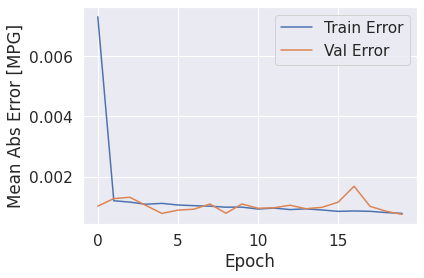

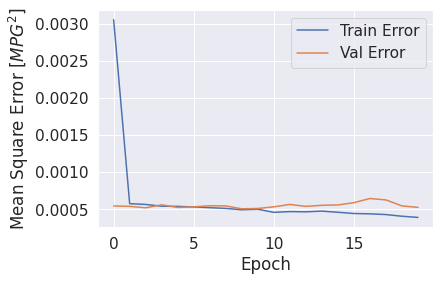

In [691]:
plot_history(history)

In [692]:
# Evaluating the model
mse = model.evaluate(X_test, y_test, verbose = 0)
print('Testing set Mean Abs Error:', mse)

Testing set Mean Abs Error: [0.0036621238104999065, 0.9994382262229919, 0.0007216540398076177, 0.00048774899914860725]


In [693]:
# Predicting the model
test_predictions = model.predict(X_test).flatten()
train_predictions = model.predict(X_train).flatten()

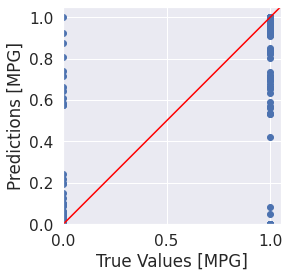

In [694]:
plt.scatter(y_test,test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
plt.plot([-100,100], [-100,100], color = 'red')
plt.show()

In [698]:
# calculating the mean-squared error, mean absolute error, and the R-Squared error on training and testing.

mse = mean_squared_error(y_test, test_predictions)
print('MSE is', mse)

MSE is 0.0004877509598928333


In [699]:
# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

In [700]:
score = model.evaluate(X_test, y_test)
score

1781/1781 [==============================] - 2s 976us/step - loss: 0.0037 - accuracy: 0.9994 - mean_absolute_error: 7.2165e-04 - mean_squared_error: 4.8775e-04


[0.0036621238104999065,
 0.9994382262229919,
 0.0007216540398076177,
 0.00048774899914860725]

In [701]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56848    13]
 [   19    82]]


In [702]:
#Let's see how our model performed
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56861
           1       0.86      0.81      0.84       101

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56861
           1       0.86      0.81      0.84       101

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



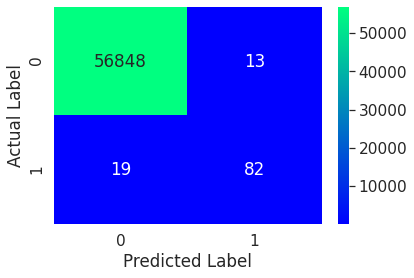

In [703]:
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = "winter", fmt = 'g')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

print(classification_report(y_test, y_pred))